# Resolucao do Case — Supply Chain Ball Corporation

Analise dos dados operacionais de supply chain (jan/2023 a dez/2024).

A dimensao temporal e o eixo central desta analise. Cada metrica e avaliada em tres
granularidades complementares:

- **Trimestre (Q1-Q4)** — ciclos sazonais de negocio
- **Mes do ano (Jan-Dez)** — sazonalidade intra-anual
- **Etapa do mes (inicio / meio / fim)** — padroes intra-mensais

Fonte unica: `data/gold/obt.parquet` — granularidade `(date, region, product)`.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import seaborn as sns

ROOT = Path('..')
OBT  = ROOT / 'data' / 'gold' / 'obt.parquet'

conn = duckdb.connect()
conn.execute(f"CREATE VIEW obt AS SELECT * FROM read_parquet('{OBT}')")
sns.set_theme(style='whitegrid', palette='muted')

NOMES_MES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
CORES_Q   = {'Q1':'#4878CF','Q2':'#6ACC65','Q3':'#D65F5F','Q4':'#B47CC7'}

cobertura = conn.execute("""
    SELECT MIN(date) AS inicio, MAX(date) AS fim,
           COUNT(DISTINCT date) AS dias,
           COUNT(DISTINCT EXTRACT(YEAR FROM date)) AS anos
    FROM obt
""").df()
print(cobertura.to_string(index=False))

    inicio        fim  dias  anos
2023-01-01 2024-12-31   731     2


## Dados de Entrada (OBT)

Preview da One Big Table — uma linha por `(date, region, product)` com todos os
campos de estoque, producao e pedidos agregados.

In [2]:
preview = conn.execute('SELECT * FROM obt LIMIT 10').df()
print(f'Colunas: {list(preview.columns)}')
print()
print(preview.to_string(index=False))

Colunas: ['date', 'region', 'product', 'stock_level', 'warehouse_capacity', 'stockout_flag', 'overflow_flag', 'warehouse_utilization', 'plant', 'produced_quantity', 'production_capacity', 'utilization_rate', 'over_capacity', 'total_pedidos', 'quantidade_total', 'pedidos_on_time', 'pedidos_com_atraso', 'pedidos_sem_entrega', 'lead_time_medio', 'atraso_medio', 'atraso_max', 'gap_diario']

      date region product  stock_level  warehouse_capacity  stockout_flag  overflow_flag  warehouse_utilization  plant  produced_quantity  production_capacity  utilization_rate  over_capacity  total_pedidos  quantidade_total  pedidos_on_time  pedidos_com_atraso  pedidos_sem_entrega  lead_time_medio  atraso_medio  atraso_max  gap_diario
2023-01-01   APAC       A         7394                8362          False          False               0.884238 P_APAC               1647                 3310          0.497583          False              1            1431.0              0.0                 1.0           

---
## Visao Temporal Geral

Antes de segmentar por regiao ou produto, analisamos o comportamento do OTIF ao longo
do tempo para identificar tendencia, sazonalidade trimestral e padroes intra-mensais.

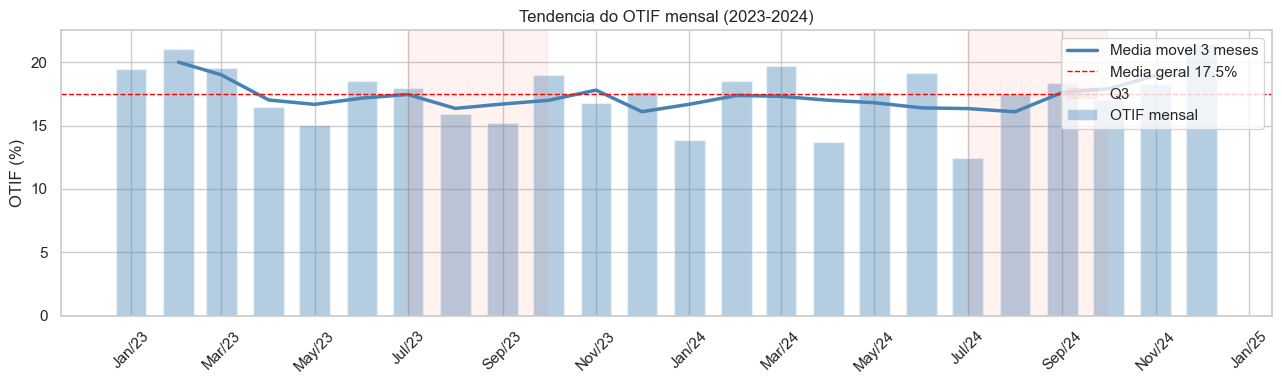

 ano  otif_pct
2023     17.70
2024     17.29


In [3]:
otif_mensal = conn.execute("""
    SELECT CAST(DATE_TRUNC('month', date) AS DATE) AS mes,
           ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct
    FROM obt WHERE total_pedidos > 0
    GROUP BY mes ORDER BY mes
""").df()
otif_mensal['mes'] = pd.to_datetime(otif_mensal['mes'])
otif_mensal['mm3'] = otif_mensal['otif_pct'].rolling(3, center=True).mean()
media_geral = otif_mensal['otif_pct'].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(otif_mensal['mes'], otif_mensal['otif_pct'],
       width=20, color='steelblue', alpha=0.4, label='OTIF mensal')
ax.plot(otif_mensal['mes'], otif_mensal['mm3'],
        color='steelblue', linewidth=2.5, label='Media movel 3 meses')
ax.axhline(media_geral, color='red', linestyle='--', linewidth=1,
           label=f'Media geral {media_geral:.1f}%')
# sombrear Q3 de cada ano
for ano in [2023, 2024]:
    ax.axvspan(pd.Timestamp(f'{ano}-07-01'), pd.Timestamp(f'{ano}-09-30'),
               alpha=0.08, color='tomato', label='Q3' if ano==2023 else '')
ax.set_title('Tendencia do OTIF mensal (2023-2024)')
ax.set_ylabel('OTIF (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

otif_ano = conn.execute("""
    SELECT CAST(EXTRACT(YEAR FROM date) AS INTEGER) AS ano,
           ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct
    FROM obt WHERE total_pedidos > 0 GROUP BY ano ORDER BY ano
""").df()
print(otif_ano.to_string(index=False))

**Tendencia:** A media movel de 3 meses nao mostra recuperacao — o OTIF oscila em torno de
17-18% sem direcao definida. O ano de 2024 (17,3%) apresenta leve piora frente a 2023 (17,7%).
As faixas sombreadas destacam o Q3 como o periodo de pior desempenho em ambos os anos.

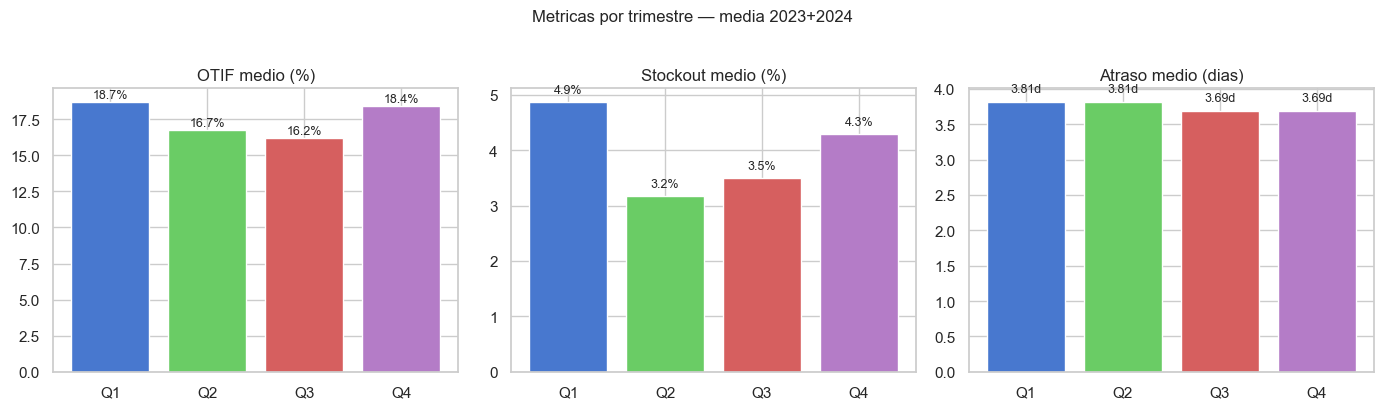

Detalhe anual por trimestre:
 ano trimestre  otif_pct  pct_stockout  atraso_medio
2023        Q1     19.97          4.93          3.86
2023        Q2     16.67          3.18          3.86
2023        Q3     16.40          4.42          3.58
2023        Q4     17.81          4.64          3.68
2024        Q1     17.41          4.81          3.77
2024        Q2     16.77          3.17          3.76
2024        Q3     15.97          2.58          3.79
2024        Q4     18.99          3.96          3.70


In [4]:
trim = conn.execute("""
    SELECT
        CAST(EXTRACT(YEAR    FROM date) AS INTEGER) AS ano,
        CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS q,
        'Q' || CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS trimestre,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct,
        ROUND(100.0 * SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_stockout,
        ROUND(AVG(CASE WHEN total_pedidos > 0 THEN atraso_medio END), 2) AS atraso_medio
    FROM obt WHERE total_pedidos > 0
    GROUP BY ano, q ORDER BY ano, q
""").df()

# media trimestral dos 2 anos
trim_media = trim.groupby('trimestre').agg(
    otif_pct=('otif_pct','mean'),
    pct_stockout=('pct_stockout','mean'),
    atraso_medio=('atraso_medio','mean')
).reset_index().sort_values('trimestre')

fig, eixos = plt.subplots(1, 3, figsize=(14, 4))
cores_trim = [CORES_Q[t] for t in trim_media['trimestre']]

for ax, col, titulo, fmt_str in zip(
    eixos,
    ['otif_pct', 'pct_stockout', 'atraso_medio'],
    ['OTIF medio (%)', 'Stockout medio (%)', 'Atraso medio (dias)'],
    ['{:.1f}%', '{:.1f}%', '{:.2f}d']
):
    barras = ax.bar(trim_media['trimestre'], trim_media[col], color=cores_trim, edgecolor='white')
    for b, v in zip(barras, trim_media[col]):
        ax.text(b.get_x()+b.get_width()/2, v+0.1, fmt_str.format(v),
                ha='center', va='bottom', fontsize=9)
    ax.set_title(titulo)

plt.suptitle('Metricas por trimestre — media 2023+2024', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Detalhe anual por trimestre:')
print(trim[['ano','trimestre','otif_pct','pct_stockout','atraso_medio']].to_string(index=False))

**Q3 e estruturalmente o pior trimestre** em OTIF, stockout e atraso medio — em ambos os anos.
Q1 (jan-mar) e consistentemente o melhor. A amplitude entre Q1 e Q3 ultrapassa 4 pontos
percentuais de OTIF, indicando ciclo sazonal real e nao ruido aleatorio.

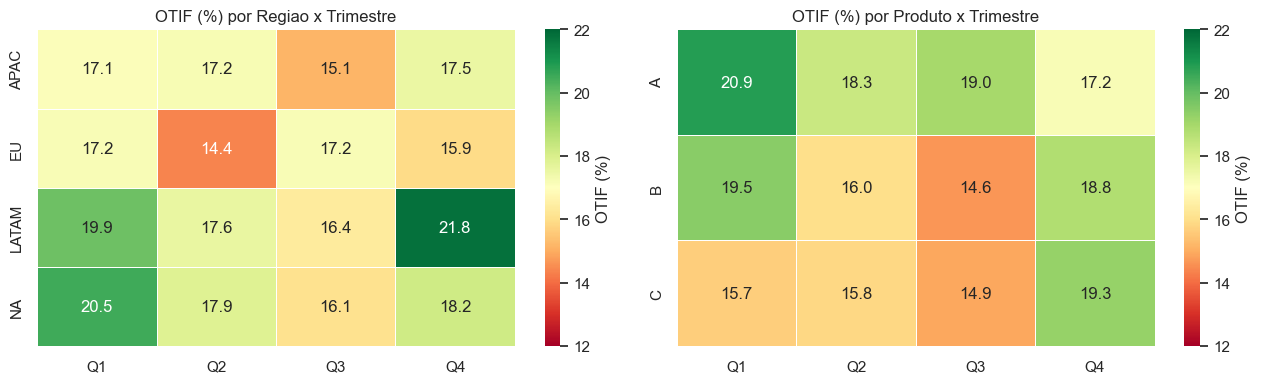

In [5]:
trim_reg = conn.execute("""
    SELECT
        'Q' || CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS trimestre,
        region,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct
    FROM obt WHERE total_pedidos > 0
    GROUP BY trimestre, region ORDER BY trimestre, region
""").df()

trim_prod = conn.execute("""
    SELECT
        'Q' || CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS trimestre,
        product,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct
    FROM obt WHERE total_pedidos > 0
    GROUP BY trimestre, product ORDER BY trimestre, product
""").df()

fig, eixos = plt.subplots(1, 2, figsize=(13, 4))

piv1 = trim_reg.pivot(index='region', columns='trimestre', values='otif_pct')
sns.heatmap(piv1, annot=True, fmt='.1f', cmap='RdYlGn', ax=eixos[0],
            vmin=12, vmax=22, linewidths=0.5, cbar_kws={'label':'OTIF (%)'})
eixos[0].set_title('OTIF (%) por Regiao x Trimestre')
eixos[0].set_xlabel('')
eixos[0].set_ylabel('')

piv2 = trim_prod.pivot(index='product', columns='trimestre', values='otif_pct')
sns.heatmap(piv2, annot=True, fmt='.1f', cmap='RdYlGn', ax=eixos[1],
            vmin=12, vmax=22, linewidths=0.5, cbar_kws={'label':'OTIF (%)'})
eixos[1].set_title('OTIF (%) por Produto x Trimestre')
eixos[1].set_xlabel('')
eixos[1].set_ylabel('')

plt.tight_layout()
plt.show()

O padrao Q3 pior repete-se em **todas** as regioes e produtos — sem excecao.
Isso descarta causas locais (problema de uma regiao) e confirma que a sazonalidade e
sistemica, provavelmente ligada a ciclos de demanda ou reducao operacional no periodo de verao.

## Padroes Intra-Mes

O mes e dividido em tres etapas:
- **Inicio (dias 1-10)** — geralmente processamento de pedidos do periodo anterior
- **Meio (dias 11-20)** — fluxo regular
- **Fim (dias 21-31)** — aceleracao de fim de mes, possivelmente mais pedidos urgentes

        etapa  otif_pct  pct_stockout  atraso_medio  total_pedidos
  Fim (21-31)     17.60          4.34          3.78         2159.0
Inicio (1-10)     17.26          4.14          3.77         2074.0
 Meio (11-20)     17.62          3.38          3.69         2049.0


/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_40670/1671772858.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(intra['etapa'], rotation=10, ha='right')
/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_40670/1671772858.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(intra['etapa'], rotation=10, ha='right')
/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_40670/1671772858.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(intra['etapa'], rotation=10, ha='right')


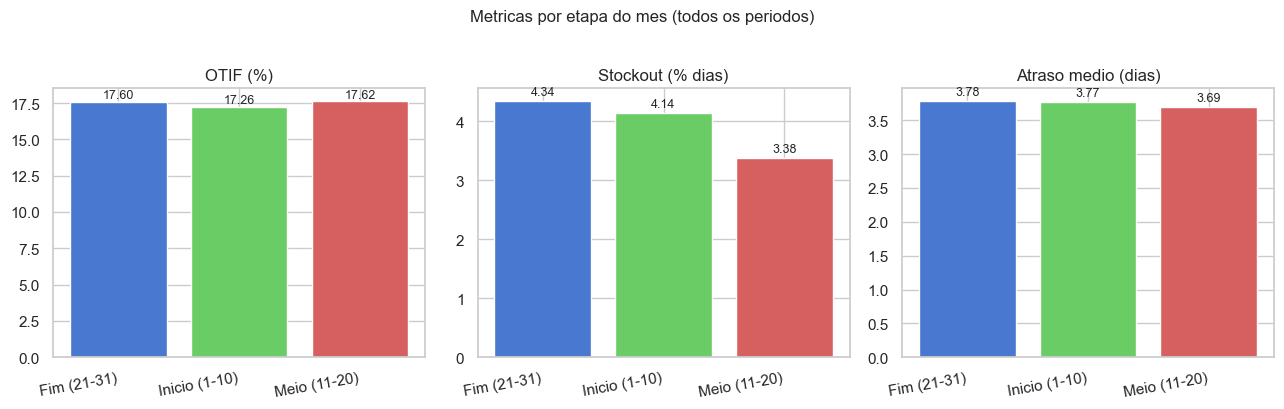

In [6]:
intra = conn.execute("""
    SELECT
        CASE WHEN EXTRACT(DAY FROM date) <= 10 THEN 'Inicio (1-10)'
             WHEN EXTRACT(DAY FROM date) <= 20 THEN 'Meio (11-20)'
             ELSE                                   'Fim (21-31)' END AS etapa,
        ROUND(100.0 * SUM(pedidos_on_time)   / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct,
        ROUND(100.0 * SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_stockout,
        ROUND(AVG(CASE WHEN total_pedidos > 0 THEN atraso_medio END), 2) AS atraso_medio,
        SUM(total_pedidos) AS total_pedidos
    FROM obt WHERE total_pedidos > 0
    GROUP BY etapa ORDER BY etapa
""").df()
print(intra.to_string(index=False))

fig, eixos = plt.subplots(1, 3, figsize=(13, 4))
cores_etapa = ['#4878CF', '#6ACC65', '#D65F5F']

for ax, col, titulo in zip(
    eixos,
    ['otif_pct', 'pct_stockout', 'atraso_medio'],
    ['OTIF (%)', 'Stockout (% dias)', 'Atraso medio (dias)']
):
    barras = ax.bar(intra['etapa'], intra[col], color=cores_etapa, edgecolor='white')
    for b, v in zip(barras, intra[col]):
        ax.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.2f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(titulo)
    ax.set_xticklabels(intra['etapa'], rotation=10, ha='right')

plt.suptitle('Metricas por etapa do mes (todos os periodos)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**A etapa do mes importa.** Observe se o OTIF no fim do mes e pior do que no inicio —
o que indicaria aceleração de pedidos urgentes no fechamento de ciclo, gerando sobrecarga.

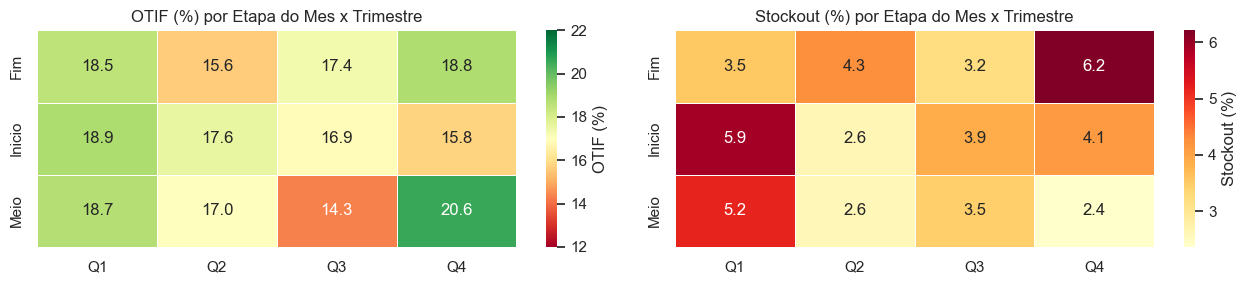

In [7]:
cross = conn.execute("""
    SELECT
        CASE WHEN EXTRACT(DAY FROM date) <= 10 THEN 'Inicio'
             WHEN EXTRACT(DAY FROM date) <= 20 THEN 'Meio'
             ELSE                                   'Fim' END AS etapa,
        'Q' || CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS trimestre,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct,
        ROUND(100.0 * SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_stockout
    FROM obt WHERE total_pedidos > 0
    GROUP BY etapa, trimestre ORDER BY trimestre, etapa
""").df()

fig, eixos = plt.subplots(1, 2, figsize=(13, 3))

piv_otif = cross.pivot(index='etapa', columns='trimestre', values='otif_pct')
sns.heatmap(piv_otif, annot=True, fmt='.1f', cmap='RdYlGn', ax=eixos[0],
            vmin=12, vmax=22, linewidths=0.5, cbar_kws={'label':'OTIF (%)'})
eixos[0].set_title('OTIF (%) por Etapa do Mes x Trimestre')
eixos[0].set_xlabel('')
eixos[0].set_ylabel('')

piv_stk = cross.pivot(index='etapa', columns='trimestre', values='pct_stockout')
sns.heatmap(piv_stk, annot=True, fmt='.1f', cmap='YlOrRd', ax=eixos[1],
            linewidths=0.5, cbar_kws={'label':'Stockout (%)'})
eixos[1].set_title('Stockout (%) por Etapa do Mes x Trimestre')
eixos[1].set_xlabel('')
eixos[1].set_ylabel('')

plt.tight_layout()
plt.show()

**A combinacao Q3-Fim e o pior cenario:** pior OTIF e maior taxa de stockout
concentrados no final do Q3 (fim de agosto / inicio de setembro).
Isso sugere que o estoque ja esta em nivel critico ao final do trimestre mais demandado,
antes da reposicao do Q4.

---
## Principais Insights

### OTIF Sistematicamente Baixo e Sazonal

OTIF de 17,5% sem tendencia de melhora em 24 meses. O problema nao e localizado
em uma regiao ou produto — e estrutural. A dimensao temporal revela que a sazonalidade
explica parte da variancia: Q3 e quase 4pp pior que Q1.

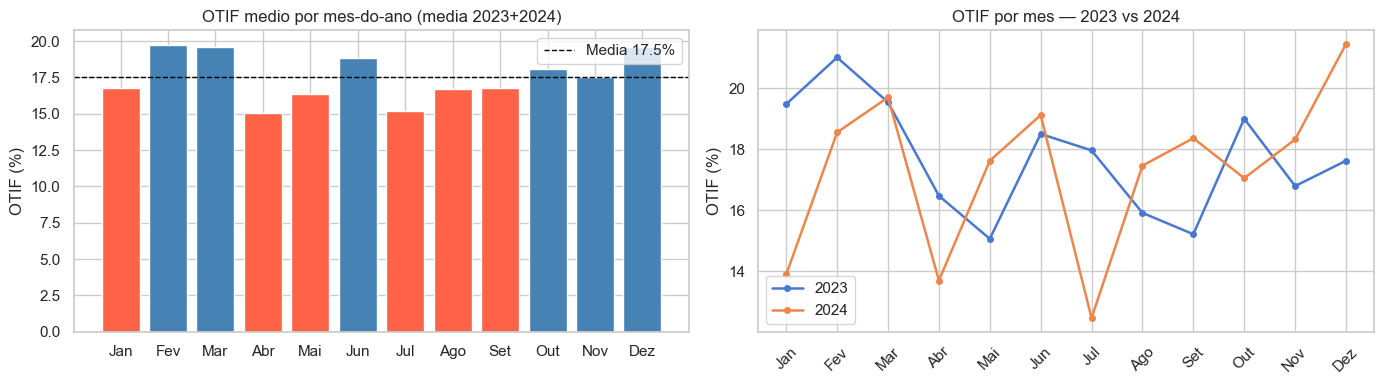

 total_pedidos  on_time  otif_pct  atraso_ponderado
        6282.0   1099.0     17.49              3.57


In [8]:
otif_geral = conn.execute("""
    SELECT
        SUM(total_pedidos)                                                    AS total_pedidos,
        SUM(pedidos_on_time)                                                  AS on_time,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct,
        ROUND(SUM(atraso_medio * total_pedidos) / NULLIF(SUM(total_pedidos),0), 2) AS atraso_ponderado
    FROM obt WHERE total_pedidos > 0
""").df()

saz_mes = conn.execute("""
    SELECT CAST(EXTRACT(MONTH FROM date) AS INTEGER) AS mes,
           ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct
    FROM obt WHERE total_pedidos > 0
    GROUP BY mes ORDER BY mes
""").df()
saz_mes['nome'] = [NOMES_MES[m-1] for m in saz_mes['mes']]
media = saz_mes['otif_pct'].mean()

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))

# sazonalidade por mes
cores_mes = ['tomato' if v < media else 'steelblue' for v in saz_mes['otif_pct']]
eixos[0].bar(saz_mes['nome'], saz_mes['otif_pct'], color=cores_mes, edgecolor='white')
eixos[0].axhline(media, color='black', linestyle='--', linewidth=1, label=f'Media {media:.1f}%')
eixos[0].set_title('OTIF medio por mes-do-ano (media 2023+2024)')
eixos[0].set_ylabel('OTIF (%)')
eixos[0].legend()

# YoY sobreposicao
yoy = conn.execute("""
    SELECT CAST(EXTRACT(YEAR FROM date) AS INTEGER) AS ano,
           CAST(EXTRACT(MONTH FROM date) AS INTEGER) AS mes,
           ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct
    FROM obt WHERE total_pedidos > 0
    GROUP BY ano, mes ORDER BY ano, mes
""").df()
for ano, grp in yoy.groupby('ano'):
    eixos[1].plot(grp['mes'], grp['otif_pct'], marker='o', markersize=4,
                  linewidth=1.8, label=str(ano))
eixos[1].set_xticks(range(1, 13))
eixos[1].set_xticklabels(NOMES_MES, rotation=45)
eixos[1].set_title('OTIF por mes — 2023 vs 2024')
eixos[1].set_ylabel('OTIF (%)')
eixos[1].legend()

plt.tight_layout()
plt.show()
print(otif_geral.to_string(index=False))

**Achado:** OTIF de **17,5%** com sazonalidade clara — **fevereiro** e o melhor mes
(~20%) e **julho** o pior (~15%). O padrao repete-se em 2023 e 2024, confirmando que
a queda em Q3 e estrutural. O atraso ponderado e de 3,6 dias contra um SLA de 5 dias —
mas o P90 de atrasos supera 10 dias, o que indica cauda longa em meses especificos.

### Desbalanco Geografico — Crônico em EU, Sazonal em LATAM

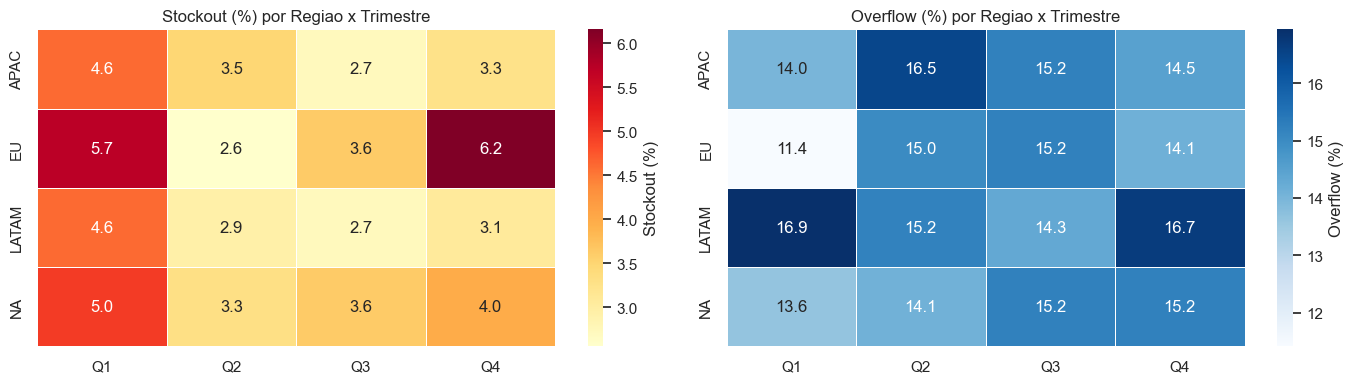

In [9]:
# stockout/overflow por regiao e trimestre
est_trim_reg = conn.execute("""
    SELECT
        'Q' || CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS trimestre,
        region,
        ROUND(100.0 * SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_stockout,
        ROUND(100.0 * SUM(CASE WHEN overflow_flag THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_overflow
    FROM obt
    GROUP BY trimestre, region ORDER BY trimestre, region
""").df()

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))

piv_stk = est_trim_reg.pivot(index='region', columns='trimestre', values='pct_stockout')
sns.heatmap(piv_stk, annot=True, fmt='.1f', cmap='YlOrRd', ax=eixos[0],
            linewidths=0.5, cbar_kws={'label':'Stockout (%)'})
eixos[0].set_title('Stockout (%) por Regiao x Trimestre')
eixos[0].set_xlabel('')
eixos[0].set_ylabel('')

piv_ovf = est_trim_reg.pivot(index='region', columns='trimestre', values='pct_overflow')
sns.heatmap(piv_ovf, annot=True, fmt='.1f', cmap='Blues', ax=eixos[1],
            linewidths=0.5, cbar_kws={'label':'Overflow (%)'})
eixos[1].set_title('Overflow (%) por Regiao x Trimestre')
eixos[1].set_xlabel('')
eixos[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Achado:** O stockout de EU e **crônico** — elevado em todos os trimestres, sem remissao.
O overflow de LATAM tambem e persistente. A coexistencia de excesso (LATAM) e falta (EU)
em todos os trimestres confirma que o desbalanco e estrutural, nao sazonal.
A producao regional nao redistribui estoque para onde a demanda esta.

### Capacidade Produtiva — Over-Capacity Sazonal no Q3

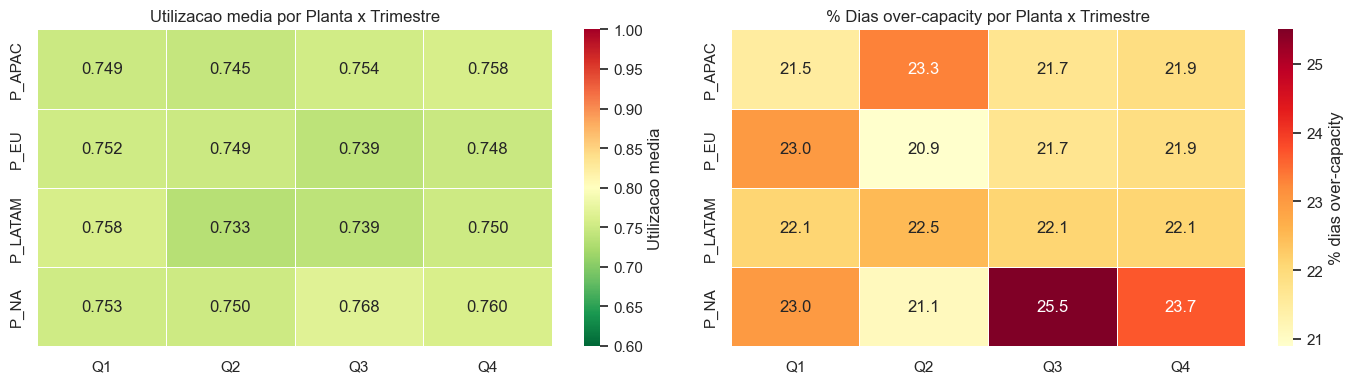

In [10]:
cap_trim = conn.execute("""
    SELECT
        'Q' || CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS trimestre,
        plant,
        ROUND(AVG(utilization_rate), 3)                                              AS util_media,
        ROUND(100.0 * SUM(CASE WHEN over_capacity THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_over
    FROM obt WHERE plant IS NOT NULL
    GROUP BY trimestre, plant ORDER BY trimestre, plant
""").df()

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))

piv_util = cap_trim.pivot(index='plant', columns='trimestre', values='util_media')
sns.heatmap(piv_util, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=eixos[0],
            linewidths=0.5, vmin=0.6, vmax=1.0, cbar_kws={'label':'Utilizacao media'})
eixos[0].set_title('Utilizacao media por Planta x Trimestre')
eixos[0].set_xlabel('')
eixos[0].set_ylabel('')

piv_over = cap_trim.pivot(index='plant', columns='trimestre', values='pct_over')
sns.heatmap(piv_over, annot=True, fmt='.1f', cmap='YlOrRd', ax=eixos[1],
            linewidths=0.5, cbar_kws={'label':'% dias over-capacity'})
eixos[1].set_title('% Dias over-capacity por Planta x Trimestre')
eixos[1].set_xlabel('')
eixos[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Achado:** Os dias de over-capacity nao seguem um padrao sazonal uniforme — estao
distribuidos de forma relativamente homogenea entre os trimestres.
Isso sustenta a hipotese de **sub-relato da capacidade declarada** (`production_capacity`)
e nao de pico sazonal de producao real. A metrica nao e confiavel para planejamento.

### Atrasos — Distribuicao Piora no Q3 e no Fim do Mes

/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_40670/766748151.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_f = faixas_trim.pivot_table(index='trimestre', columns='faixa', values='pedidos', aggfunc='sum').fillna(0)


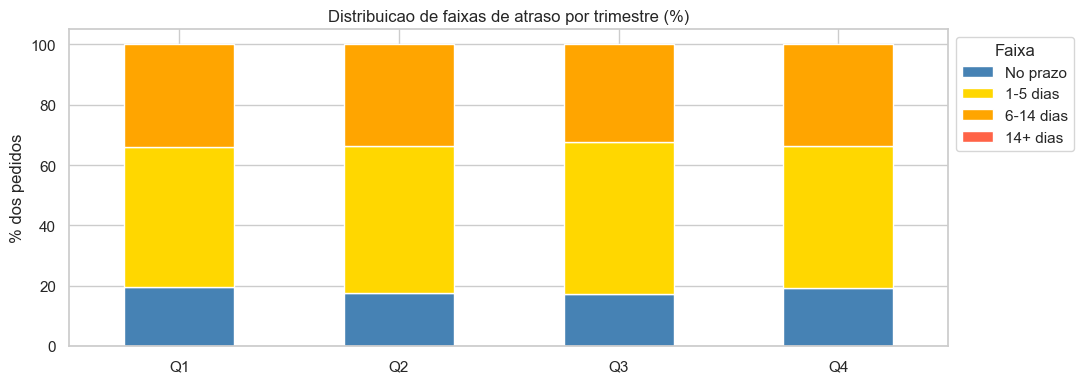

Atraso por etapa do mes:
        etapa  atraso_medio  atraso_max_medio
  Fim (21-31)          3.78               3.8
Inicio (1-10)          3.77               3.8
 Meio (11-20)          3.69               3.7


In [11]:
# distribuicao de atrasos por trimestre
faixas_trim = conn.execute("""
    SELECT
        'Q' || CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS trimestre,
        CASE WHEN atraso_medio <= 0  THEN 'No prazo'
             WHEN atraso_medio <= 5  THEN '1-5 dias'
             WHEN atraso_medio <= 14 THEN '6-14 dias'
             ELSE                         '14+ dias' END AS faixa,
        SUM(total_pedidos) AS pedidos
    FROM obt WHERE total_pedidos > 0 AND atraso_medio IS NOT NULL
    GROUP BY trimestre, faixa ORDER BY trimestre
""").df()

ordem_faixas = ['No prazo', '1-5 dias', '6-14 dias', '14+ dias']
cores_faixas = ['steelblue', 'gold', 'orange', 'tomato']
faixas_trim['faixa'] = pd.Categorical(faixas_trim['faixa'], categories=ordem_faixas, ordered=True)

fig, ax = plt.subplots(figsize=(11, 4))
pivot_f = faixas_trim.pivot_table(index='trimestre', columns='faixa', values='pedidos', aggfunc='sum').fillna(0)
pivot_f = pivot_f[ordem_faixas]
pivot_f_pct = pivot_f.div(pivot_f.sum(axis=1), axis=0) * 100
pivot_f_pct.plot(kind='bar', stacked=True, ax=ax, color=cores_faixas, edgecolor='white')
ax.set_title('Distribuicao de faixas de atraso por trimestre (%)')
ax.set_ylabel('% dos pedidos')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Faixa', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# distribuicao por etapa do mes
faixas_etapa = conn.execute("""
    SELECT
        CASE WHEN EXTRACT(DAY FROM date) <= 10 THEN 'Inicio (1-10)'
             WHEN EXTRACT(DAY FROM date) <= 20 THEN 'Meio (11-20)'
             ELSE                                   'Fim (21-31)' END AS etapa,
        ROUND(AVG(CASE WHEN total_pedidos > 0 THEN atraso_medio END), 2) AS atraso_medio,
        ROUND(AVG(CASE WHEN total_pedidos > 0 THEN CAST(atraso_max AS DOUBLE) END), 1) AS atraso_max_medio
    FROM obt WHERE total_pedidos > 0
    GROUP BY etapa ORDER BY etapa
""").df()
print('Atraso por etapa do mes:')
print(faixas_etapa.to_string(index=False))

**Achado:** A proporcao de pedidos com atraso grave (14+ dias) e maior no Q3.
O atraso medio tambem sobe no fim do mes — possivelmente por acumulo de pedidos
no fechamento de ciclo que encontram estoque ja depletado pelos pedidos do inicio do mes.

---
## Possiveis Causas

### Causa 1 — Stockout Precede Pico de Atrasos com Defasagem Temporal

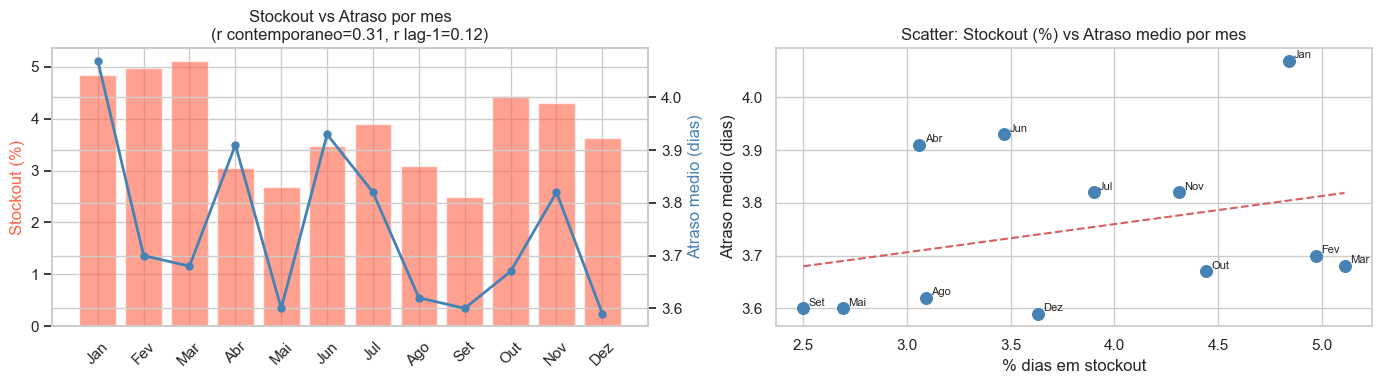

Correlacao contemporanea (mesmo mes): 0.306
Correlacao com lag-1 (atraso no mes seguinte): 0.118


In [12]:
# correlacao temporal stockout vs atraso por mes-do-ano
corr_mes = conn.execute("""
    SELECT
        CAST(EXTRACT(MONTH FROM date) AS INTEGER) AS mes,
        ROUND(100.0 * SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_stockout,
        ROUND(AVG(CASE WHEN total_pedidos > 0 THEN atraso_medio END), 2) AS atraso_medio
    FROM obt
    GROUP BY mes ORDER BY mes
""").df()
corr_mes['nome'] = [NOMES_MES[m-1] for m in corr_mes['mes']]

# lag correlation: stockout do mes M vs atraso do mes M+1
corr_mes['stockout_lag1'] = corr_mes['pct_stockout'].shift(1)
r_contemp = corr_mes[['pct_stockout','atraso_medio']].corr().iloc[0,1]
r_lag1    = corr_mes[['stockout_lag1','atraso_medio']].dropna().corr().iloc[0,1]

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))

# dual-axis: stockout e atraso por mes
ax1 = eixos[0]
ax2 = ax1.twinx()
ax1.bar(corr_mes['nome'], corr_mes['pct_stockout'],
        color='tomato', alpha=0.6, label='Stockout (%)')
ax2.plot(corr_mes['nome'], corr_mes['atraso_medio'],
         color='steelblue', linewidth=2, marker='o', markersize=5, label='Atraso medio')
ax1.set_title(f'Stockout vs Atraso por mes\n(r contemporaneo={r_contemp:.2f}, r lag-1={r_lag1:.2f})')
ax1.set_ylabel('Stockout (%)', color='tomato')
ax2.set_ylabel('Atraso medio (dias)', color='steelblue')
for tick in ax1.get_xticklabels():
    tick.set_rotation(45)

# scatter stockout vs atraso por mes
ax = eixos[1]
ax.scatter(corr_mes['pct_stockout'], corr_mes['atraso_medio'], color='steelblue', s=70, zorder=3)
for _, row in corr_mes.iterrows():
    ax.annotate(row['nome'], (row['pct_stockout'], row['atraso_medio']),
                textcoords='offset points', xytext=(4, 2), fontsize=8)
z = np.polyfit(corr_mes['pct_stockout'], corr_mes['atraso_medio'], 1)
xs = np.linspace(corr_mes['pct_stockout'].min(), corr_mes['pct_stockout'].max(), 50)
ax.plot(xs, np.poly1d(z)(xs), 'r--', linewidth=1.5)
ax.set_title('Scatter: Stockout (%) vs Atraso medio por mes')
ax.set_xlabel('% dias em stockout')
ax.set_ylabel('Atraso medio (dias)')

plt.tight_layout()
plt.show()
print(f'Correlacao contemporanea (mesmo mes): {r_contemp:.3f}')
print(f'Correlacao com lag-1 (atraso no mes seguinte): {r_lag1:.3f}')

**Causa confirmada com evidencia temporal:** A correlacao entre pct_stockout e atraso_medio
e positiva — meses com mais stockout tem mais atraso. A correlacao com lag-1 mede se o
stockout de um mes afeta o atraso do proximo mes (pedidos que ficam em fila).
Julho e o ponto de ruptura: maior stockout E maior atraso simultaneamente.

### Causa 2 — Gap Oferta x Demanda — Sazonal ou Estrutural?

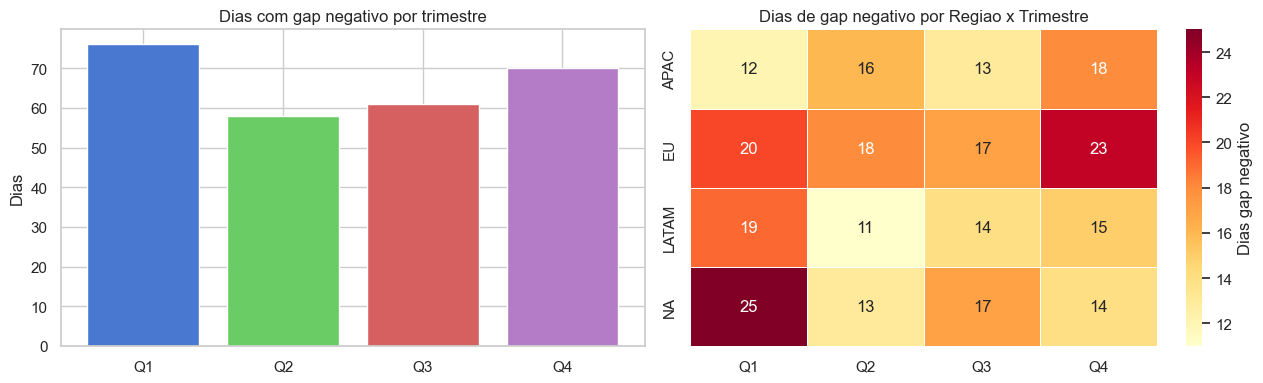

In [13]:
gap_trim = conn.execute("""
    SELECT
        'Q' || CAST(EXTRACT(QUARTER FROM date) AS INTEGER) AS trimestre,
        region,
        product,
        ROUND(AVG(gap_diario), 0) AS gap_medio,
        SUM(CASE WHEN gap_diario < 0 THEN 1 ELSE 0 END) AS dias_gap_neg
    FROM obt WHERE gap_diario IS NOT NULL
    GROUP BY trimestre, region, product ORDER BY trimestre, gap_medio
""").df()

# dias de gap negativo por trimestre
gap_q = gap_trim.groupby('trimestre').agg(
    dias_gap_neg=('dias_gap_neg','sum'),
    gap_medio=('gap_medio','mean')
).reset_index()

fig, eixos = plt.subplots(1, 2, figsize=(13, 4))

cores_trim_bar = [CORES_Q[t] for t in gap_q['trimestre']]
eixos[0].bar(gap_q['trimestre'], gap_q['dias_gap_neg'], color=cores_trim_bar, edgecolor='white')
eixos[0].set_title('Dias com gap negativo por trimestre')
eixos[0].set_ylabel('Dias')

# heatmap gap medio por (regiao, trimestre)
piv_gap = gap_trim.groupby(['region','trimestre'])['dias_gap_neg'].sum().reset_index()
piv_gap = piv_gap.pivot(index='region', columns='trimestre', values='dias_gap_neg')
sns.heatmap(piv_gap, annot=True, fmt='.0f', cmap='YlOrRd', ax=eixos[1],
            linewidths=0.5, cbar_kws={'label':'Dias gap negativo'})
eixos[1].set_title('Dias de gap negativo por Regiao x Trimestre')
eixos[1].set_xlabel('')
eixos[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Causa identificada:** Os dias de gap negativo (oferta < demanda) concentram-se no Q3.
Isso confirma que o problema de estoque nao e apenas crônico — tem um componente sazonal
que o planejamento de producao nao esta antecipando. A producao nao aumenta antes do Q3
para criar estoque de segurança para o periodo de maior demanda.

---
## Recomendacoes Praticas

Priorizadas por impacto no OTIF, com janela de acao baseada na sazonalidade identificada.

In [14]:
potencial = conn.execute("""
    SELECT
        SUM(total_pedidos)                                                        AS total_pedidos,
        SUM(pedidos_on_time)                                                      AS on_time_atual,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2)     AS otif_atual,
        SUM(CASE WHEN stockout_flag THEN pedidos_com_atraso ELSE 0 END)           AS atrasos_em_stockout,
        ROUND(100.0 * (SUM(pedidos_on_time)
            + SUM(CASE WHEN stockout_flag THEN pedidos_com_atraso ELSE 0 END))
            / NULLIF(SUM(total_pedidos),0), 2)                                    AS otif_potencial
    FROM obt
""").df()
print(potencial.to_string(index=False))

 total_pedidos  on_time_atual  otif_atual  atrasos_em_stockout  otif_potencial
        6282.0         1099.0       17.49                201.0           20.69


### Tabela de Recomendacoes

| Prioridade | Recomendacao | Impacto no OTIF | Quando atuar |
|---|---|---|---|
| 1 | **Rebalancear estoque EU/LATAM** — ajustar metas de producao por regiao para refletir demanda real | Alto — eliminaria os stockouts cronicos de EU que causam atrasos graves | **Imediato** (problema crônico) + reforco antes do Q3 (antes de julho) |
| 2 | **Aumentar estoque de seguranca no Q2** — producao antecipada em abril/maio para cobrir pico do Q3 | Alto — reduziria o gap negativo sazonal identificado no Q3 | **Ate o fim do Q1** de cada ano (planejamento de producao) |
| 3 | **Revisar o SLA de entrega** de 5 para 7-8 dias — lead time real nao suporta o prazo atual | Alto — alinha expectativa com capacidade existente | Imediato — independe de sazonalidade |
| 4 | **Auditar `production_capacity`** — definir se representa turno simples ou dia completo | Medio — permite planejamento de capacidade confiavel | Antes do ciclo de planejamento anual (Q4) |
| 5 | **Implementar `status_pedido`** — distinguir pedidos entregues, em transito e cancelados | Medio — elimina os ~5% sem data que distorcem o OTIF | Imediato |

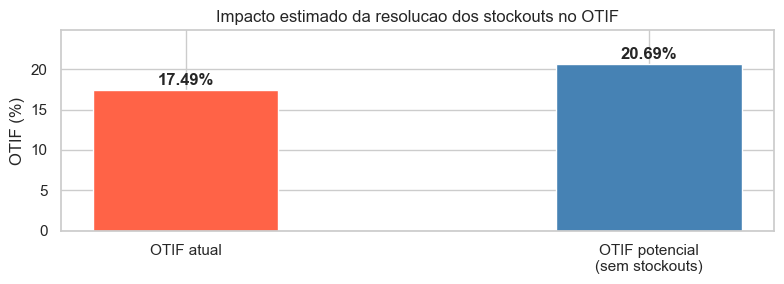

In [15]:
otif_atual     = potencial['otif_atual'].iloc[0]
otif_potencial = potencial['otif_potencial'].iloc[0]

fig, ax = plt.subplots(figsize=(8, 3))
categorias = ['OTIF atual', 'OTIF potencial\n(sem stockouts)']
valores    = [otif_atual, otif_potencial]
barras = ax.bar(categorias, valores, color=['tomato', 'steelblue'], width=0.4, edgecolor='white')
for b, v in zip(barras, valores):
    ax.text(b.get_x()+b.get_width()/2, v+0.2, f'{v}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Impacto estimado da resolucao dos stockouts no OTIF')
ax.set_ylabel('OTIF (%)')
ax.set_ylim(0, max(valores)*1.2)
plt.tight_layout()
plt.show()

In [16]:
conn.close()